In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv('student-mat.csv', sep=';')

In [3]:
print(df.head())


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [4]:

print(df.shape)


(395, 33)


In [5]:


print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:

print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [7]:
print(df['G3'].describe())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


In [8]:
X = df.drop('G3', axis=1)

y = df['G3']

In [9]:
le = LabelEncoder()

for col in X.columns:

    if X[col].dtype == 'object':

        X[col] = le.fit_transform(X[col])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 125.5718 - mae: 10.2052 - val_loss: 120.2547 - val_mae: 10.2038
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 112.9333 - mae: 9.7028 - val_loss: 102.7252 - val_mae: 9.4420
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 88.7500 - mae: 8.6316 - val_loss: 70.4211 - val_mae: 7.8006
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 51.8048 - mae: 6.4462 - val_loss: 30.3335 - val_mae: 4.8929
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 19.2842 - mae: 3.6742 - val_loss: 13.7712 - val_mae: 2.7606
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.7372 - mae: 2.5219 - val_loss: 11.0679 - val_mae: 2.4975
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.5380 - mae: 2.1659 - val_loss: 9.2928 - val_mae: 2.3805
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9746 - mae: 2.0024 - val_loss: 8.2466 - val_mae: 2.2671
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s

In [17]:
loss, mae = model.evaluate(
    X_test,
    y_test
)

print("Test MAE =", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 9.0762 - mae: 1.9919  
Test MAE = 1.9918726682662964


In [18]:
predictions = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [19]:
for i in range(10):

    print(
        "Actual Grade:",
        y_test.iloc[i],
        "Predicted Grade:",
        round(predictions[i][0],2)
    )

Actual Grade: 10 Predicted Grade: 8.39
Actual Grade: 12 Predicted Grade: 11.3
Actual Grade: 5 Predicted Grade: 1.35
Actual Grade: 10 Predicted Grade: 8.02
Actual Grade: 9 Predicted Grade: 12.32
Actual Grade: 13 Predicted Grade: 12.39
Actual Grade: 18 Predicted Grade: 19.92
Actual Grade: 6 Predicted Grade: 10.04
Actual Grade: 0 Predicted Grade: 8.27
Actual Grade: 14 Predicted Grade: 10.63


In [20]:
mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2 Score:", r2)

MSE : 9.07618522644043
RMSE: 3.0126707796306635
MAE : 1.9918724298477173
R2 Score: 0.557368278503418


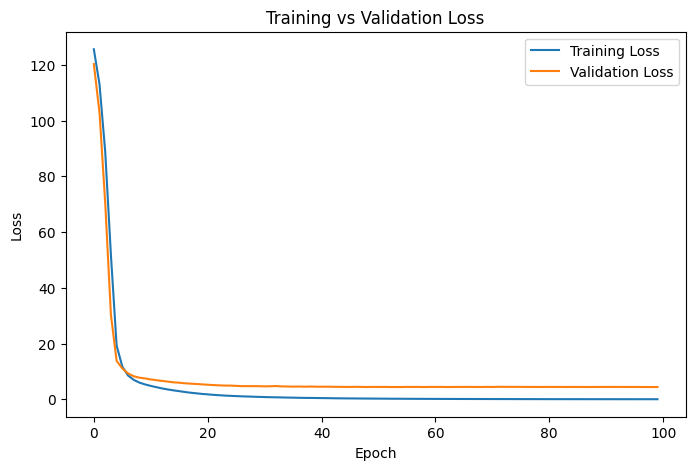

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

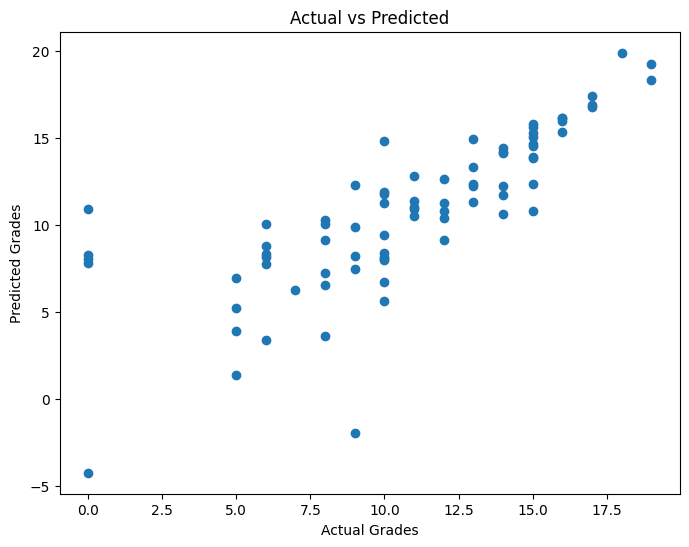

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Grades")

plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted")

plt.show()